In [1]:
import numpy as np
import pandas as pd
import matplotlib as mlp
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import KBinsDiscretizer
from scipy.linalg import orthogonal_procrustes
from sklearn.neighbors import kneighbors_graph, NearestCentroid
from sklearn.cluster import AgglomerativeClustering


In [2]:
from matplotlib.colors import XKCD_COLORS

In [3]:
fdf_3d = pd.read_csv("./datasets/within_subj_aligned_rfef.csv", header=0, index_col=0)

In [3]:
con_df = pd.read_csv("./datasets/control_dataset_random_voxels.csv", header=0, index_col=0)

In [4]:
rdf_3d = pd.read_csv("./datasets/control_dataset_random_voxels_aligned_w-in_subj.csv", header=0, index_col=0)

They seem to form twisted donuts!  Let's see if we can rotate these macro-structures.

In [4]:
fdf_aligned = pd.read_csv("./datasets/full_dataset_within_subj_aligned_rfef.csv", header=0, index_col=0)

In [5]:
vcols = ["v"+str(i) for i in range(120)]

Evidently, this form of rotation is not possible. 
Instead, let's test a few hypotheses:
1. The structure is a tube.
2. The structure is a cylindrical gradient.
3. The structure is three distinct paths that intertwine.
4. The structure is a twisted loop.
5. The structure lies on the surface of a higher dimension structure.
6. There is a relationship between the complexity of the structure and subject performance.
7. There is a nonlinear relationship between the spot on the structure and HRF response for either stimuli.

If the structure is a tube, the data should lie within + or - some epsilon from the putative surface. However, all points should be far away from the center because we expect it to be hollow. The data in 3d space allow us to find the points that are within some distance from each other. Luckily divisive clustering is a thing. Unfortunately, because of loops or possibly knots, we won't be able to measure the entirety of the tube (if it indeed is one), but if most of it is a tube...all of it is probably a tube.

In [5]:
def processed_df(df, df3d, vox=True, col=None, val=None):
    if col & val:
        X = df3d[df3d[col]==val].loc[:,['x','y','z']]
        
    elif vox:
        X = df[vcols]
    
    n_neighbors = X.shape[0]/10
    connectivity = kneighbors_graph(X, n_neighbors=n_neighbors, include_self=False)
    model = AgglomerativeClustering(n_clusters=32, 
                                    linkage='ward', 
                                    connectivity=connectivity).fit(X)
    


In [25]:
X = fdf_3d[fdf_3d['Subject']==1].loc[:,['x','y','z']]

In [7]:
X = rdf_3d[rdf_3d['Subjects']==1].loc[:,['x','y','z']]

In [35]:
connectivity = kneighbors_graph(X, n_neighbors=12, include_self=False)
model = AgglomerativeClustering(n_clusters=32, linkage='ward', connectivity=connectivity).fit(X)

In [8]:
connectivity = kneighbors_graph(X, n_neighbors=12, include_self=False)
model = AgglomerativeClustering(n_clusters=32, linkage='ward', connectivity=connectivity).fit(X)

/home/tahia/miniconda3/envs/datascience/lib/python3.13/site-packages/sklearn/cluster/_agglomerative.py:321: UserWarning: the number of connected components of the connectivity matrix is 2 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


In [36]:
sub1 = fdf_3d[fdf_3d['Subject']==1].copy()
sub1['Labels'] = model.labels_

In [9]:
rsub1 = rdf_3d[rdf_3d['Subjects']==1].copy()
rsub1['Labels'] = model.labels_

In [37]:
fig = px.scatter_3d(sub1, x='x', y='y', z='z', color='Labels', opacity=0.7, size_max=3, title="Clustered 3D t-SNE of Aligned Brain States for Subject 1")
fig.show(renderer="iframe")

In [10]:
fig = px.scatter_3d(rsub1, x='x', y='y', z='z', color='Labels', opacity=0.7, size_max=3, title="Clustered 3D t-SNE of Aligned Brain States for Subject 1")
fig.show(renderer="iframe")

Not bad. We now have segments defined. Let's go see how they're arranged.

In [51]:
sub1['delta_x_center'] = [0]*sub1.shape[0]
sub1['delta_y_center'] = [0]*sub1.shape[0]
sub1['delta_z_center'] = [0]*sub1.shape[0]

In [11]:
rsub1['delta_x_center'] = [0]*rsub1.shape[0]
rsub1['delta_y_center'] = [0]*rsub1.shape[0]
rsub1['delta_z_center'] = [0]*rsub1.shape[0]

In [52]:
centers = sub1.groupby('Labels')[['x', 'y', 'z']].mean()

In [12]:
centers = rsub1.groupby('Labels')[['x', 'y', 'z']].mean()

In [63]:
cdf = centers.loc[sub1['Labels'], ['x', 'y', 'z']]
cdf.index = sub1.index
cdf.shape

(1210, 3)

In [13]:
cdf = centers.loc[rsub1['Labels'], ['x', 'y', 'z']]
cdf.index = rsub1.index
cdf.shape

(1210, 3)

In [64]:
sub1[['delta_x_center','delta_y_center','delta_z_center']] = cdf[['x', 'y', 'z']] - sub1[['x', 'y', 'z']]

In [14]:
rsub1[['delta_x_center','delta_y_center','delta_z_center']] = cdf[['x', 'y', 'z']] - rsub1[['x', 'y', 'z']]

In [15]:
rsub1.head(10)

,x,y,z,Time,Runs,Subjects,Session,Labels,delta_x_center,delta_y_center,delta_z_center
0,0.929651,-6.339428,0.280728,0.0,1,1,1,5,1.401828,-0.667035,0.765608
1,1.267718,-5.969094,0.185755,2.2,1,1,1,5,1.063762,-1.037369,0.860582
2,-0.046825,-9.348011,1.169338,4.4,1,1,1,27,0.257967,-0.872904,0.441150
3,4.383675,11.902892,0.845595,6.6,1,1,1,18,0.251174,0.534220,-0.380923
4,-3.121629,-14.863750,0.609638,8.8,1,1,1,4,0.804208,0.871304,0.317738
5,7.616446,18.663630,-2.416820,11.0,1,1,1,21,-0.275466,-0.180817,0.248398
6,3.191801,-21.519500,-3.708389,13.2,1,1,1,11,-0.542919,0.563319,0.022497
7,2.166990,21.074268,4.981499,15.4,1,1,1,17,0.114261,0.123963,-0.104385
8,0.975431,-29.775320,-1.540359,17.6,1,1,1,25,0.677869,0.700731,-0.237529
9,0.021400,23.805935,11.887218,19.8,1,1,1,28,0.071802,0.103845,-0.034468


Text(0.5, 0, 'Distance from centroid')

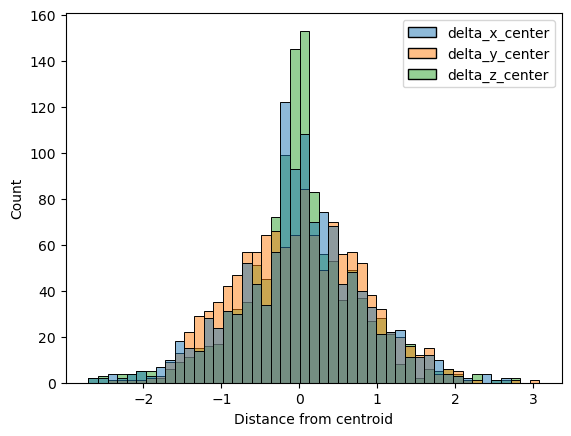

In [16]:
fig, ax = plt.subplots(1,1)
sns.histplot(rsub1[['delta_x_center','delta_y_center','delta_z_center']], ax=ax)
ax.set_xlabel("Distance from centroid")

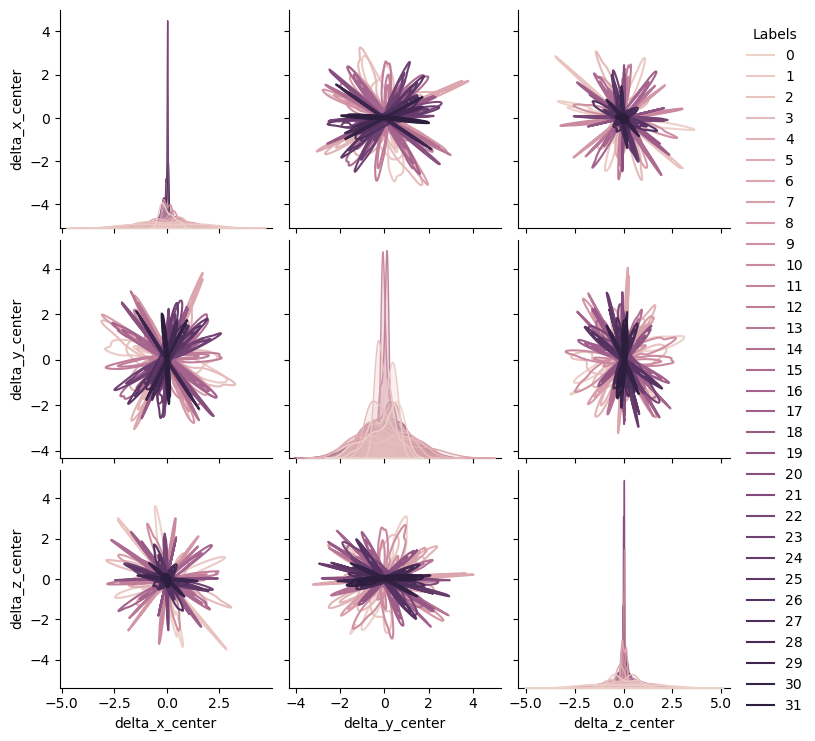

In [17]:
sns.pairplot(rsub1[['Labels','delta_x_center','delta_y_center','delta_z_center']], hue='Labels', kind='kde')

<Axes: xlabel='Labels', ylabel='delta_x_center'>

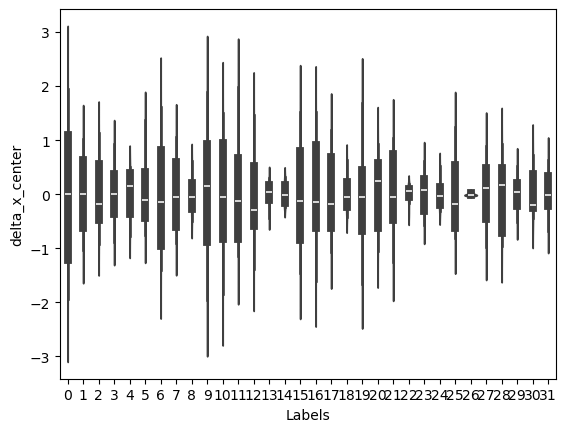

In [81]:
sns.violinplot(sub1[['Labels','delta_x_center','delta_y_center','delta_z_center']], x="Labels", y="delta_x_center")

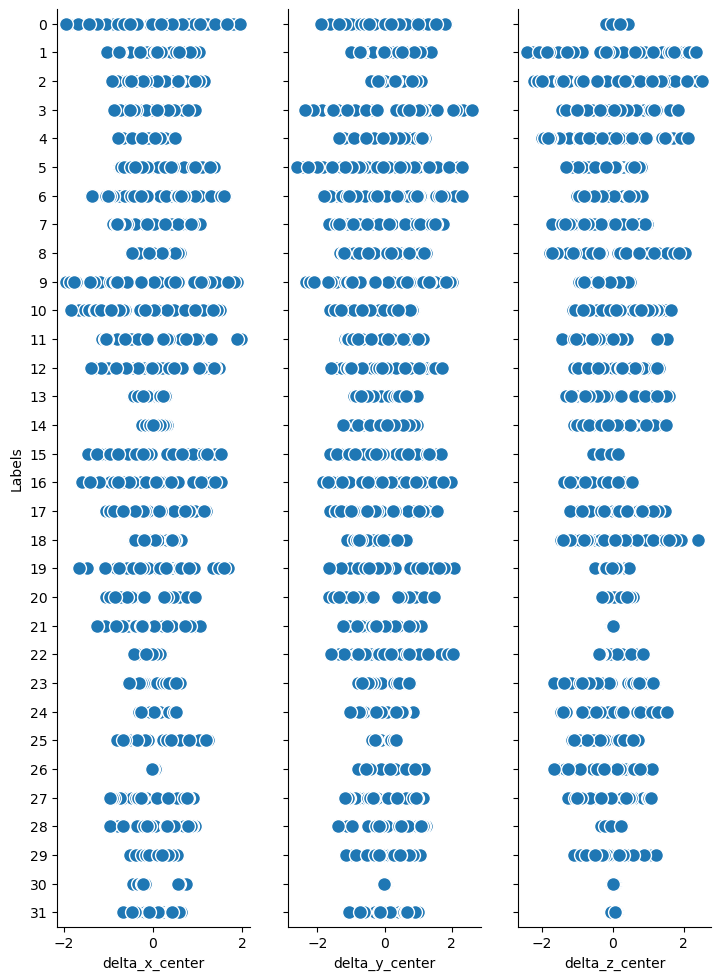

In [83]:
g = sns.PairGrid(sub1.sort_values("Labels", ascending=True),
                 x_vars=sub1.columns[-3:], y_vars=["Labels"],
                 height=10, aspect=.25)

g.map(sns.stripplot, size=10, orient="h", jitter=False,
      palette="flare_r", linewidth=1, edgecolor="w")


In [84]:
sub1.to_csv("./datasets/MSC01_Clustered_rFEF.csv")

In [23]:
sub1 = pd.read_csv("./datasets/MSC01_Clustered_rFEF.csv", index_col=0, header=0)

In [3]:
sub1.head()

,x,y,z,Time,Run,Subject,Session,Labels,delta_x_center,delta_y_center,delta_z_center
0,-1.253390,-1.406221,-2.888681,0.0,1,1,1,30,-0.190320,-0.006549,0.039915
1,-1.002485,-1.449264,-2.836150,2.2,1,1,1,30,-0.441224,0.036495,-0.012616
2,-2.177332,-1.433458,-2.827666,4.4,1,1,1,30,0.733622,0.020689,-0.021100
3,1.055743,-2.791845,-1.671083,6.6,1,1,1,11,1.026083,-0.401608,1.287953
4,-5.980712,7.948273,1.195451,8.8,1,1,1,3,0.783440,0.951882,-1.364026


In [5]:
sub1['Indoor'] = fdf_aligned['Indoor']
sub1['Outdoor'] = fdf_aligned['Outdoor']

In [18]:
rsub1['Distance_From_Center'] = np.sqrt(rsub1['delta_x_center']**2) + (rsub1['delta_y_center']**2) + (rsub1['delta_z_center']**2)

In [36]:
fig = px.scatter_3d(rsub1[(rsub1['Session']==3) | (rsub1['Session']==8)], x='x', y='y', z='z', color='Session', opacity=0.7, size_max=3, title="Clustered 3D t-SNE of Aligned Brain States for Subject 1")
fig.show(renderer="iframe")

In [33]:
fig = px.scatter_3d(sub1[(sub1['Session']==8) | (sub1['Session']==3)], x='x', y='y', z='z', color='Session', opacity=0.7, size_max=3, title="Clustered 3D t-SNE of Aligned Brain States for Subject 1")
fig.show(renderer="iframe")

In [25]:
con_df.columns

Index(['scan_time', 'indoor', 'outdoor', 'sess', 'subj', 'run', 'v8463',
       'v6877', 'v10711', 'v11779',
       ...
       'v4456', 'v3776', 'v13462', 'v1327', 'v5575', 'v12825', 'v10163',
       'v12183', 'v4309', 'v3927'],
      dtype='object', length=126)

In [6]:
sub1['Distance_From_Center'] = np.sqrt(sub1['delta_x_center']**2) + (sub1['delta_y_center']**2) + (sub1['delta_z_center']**2)

In [90]:
fig = px.scatter_3d(sub1, x='x', y='y', z='z', color='Labels', opacity=0.7, size_max=3, title="Clustered 3D t-SNE of Aligned Brain States for Subject 1")
fig.show(renderer="iframe")

In [113]:
fig = px.scatter_3d(sub1[sub1['Session']==1], x='x', y='y', z='z', color='Outdoor', opacity=0.7, size_max=3, title="Clustered 3D t-SNE of Aligned Brain States for Subject 1")
fig.show(renderer="iframe")

In [114]:
fig = px.scatter_3d(sub1[sub1['Session']==1], x='x', y='y', z='z', color='Indoor', opacity=0.7, size_max=3, title="Clustered 3D t-SNE of Aligned Brain States for Subject 1")
fig.show(renderer="iframe")

In [117]:
fig = px.scatter_3d(sub1[sub1['Session']==10], x='x', y='y', z='z', color='Outdoor', opacity=0.7, size_max=3, title="Clustered 3D t-SNE of Aligned Brain States for Subject 1")
fig.show(renderer="iframe")

In [118]:
fig = px.scatter_3d(sub1[sub1['Session']==10], x='x', y='y', z='z', color='Indoor', opacity=0.7, size_max=3, title="Clustered 3D t-SNE of Aligned Brain States for Subject 1")
fig.show(renderer="iframe")

In [121]:
fig = px.scatter_3d(sub1[sub1['Indoor']>=1.0], x='x', y='y', z='z', color='Session', opacity=0.7, size_max=3, title="Clustered 3D t-SNE of Aligned Brain States for Subject 1")
fig.show(renderer="iframe")

In [126]:
fig = px.scatter_3d(sub1[(sub1['Outdoor']>=1.0) | (sub1['Indoor']>=1.0)], x='x', y='y', z='z', color='Indoor', opacity=0.7, size_max=3, title="Clustered 3D t-SNE of Aligned Brain States for Subject 1")
fig.show(renderer="iframe")

In [7]:
sub1.Outdoor.describe()

count    1210.000000
mean        0.288566
std         0.437240
min        -0.490589
25%        -0.048468
50%         0.245219
75%         0.602690
max         1.543063
Name: Outdoor, dtype: float64

Text(0.5, 0, 'Distribution of Segment 25')

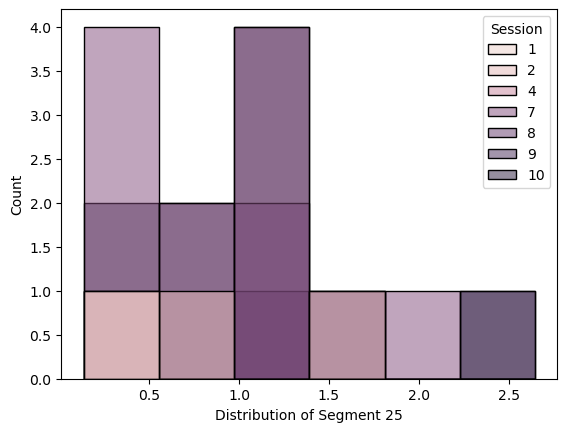

In [106]:
fig, ax = plt.subplots(1,1)
sns.histplot(data=sub1[sub1['Labels']==25], x='Distance_From_Center', hue='Session', ax=ax)
ax.set_xlabel("Distribution of Segment 25")

Text(0.5, 0, 'Distribution of Segment 26')

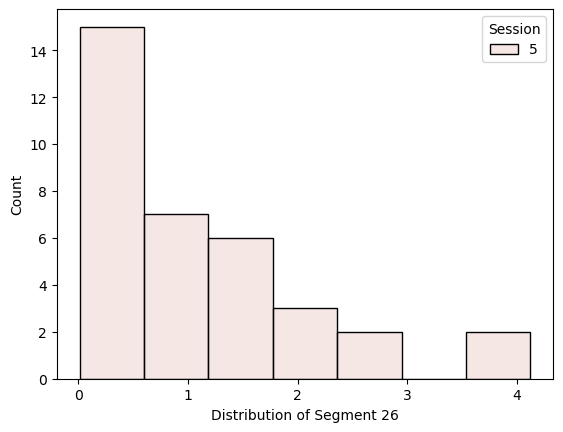

In [104]:
fig, ax = plt.subplots(1,1)
sns.histplot(data=sub1[sub1['Labels']==26], x='Distance_From_Center', hue='Session', ax=ax)
ax.set_xlabel("Distribution of Segment 26")

Text(0.5, 0, 'Distribution of Segment 18')

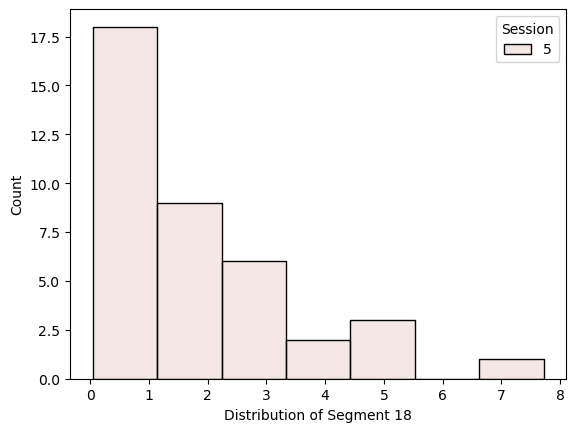

In [105]:
fig, ax = plt.subplots(1,1)
sns.histplot(data=sub1[sub1['Labels']==18], x='Distance_From_Center', hue='Session', ax=ax)
ax.set_xlabel("Distribution of Segment 18")

Text(0.5, 0, 'Distribution of Segment 19')

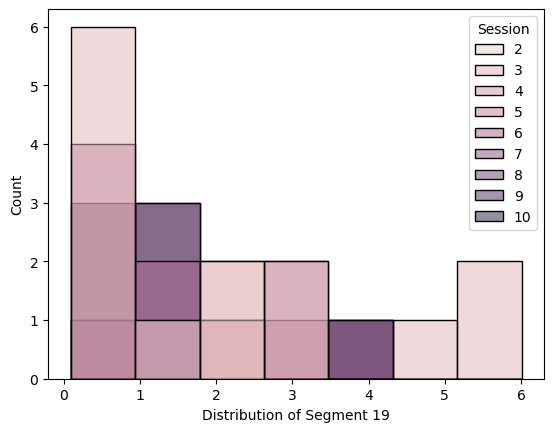

In [103]:
fig, ax = plt.subplots(1,1)
sns.histplot(data=sub1[sub1['Labels']==19], x='Distance_From_Center', hue='Session', ax=ax)
ax.set_xlabel("Distribution of Segment 19")

In [9]:
fig = px.scatter_3d(sub1[(sub1['Outdoor']>=1.0) | (sub1['Indoor']>=1.0)], x='x', y='y', z='z', color='Session', opacity=0.7, size_max=3, title="Clustered 3D t-SNE of Aligned Brain States for Subject 1")
fig.show(renderer="iframe")

In [22]:
fig = px.scatter_3d(sub1[(sub1['Session']==10)], x='x', y='y', z='z', color='Indoor', opacity=0.7, size_max=3, title="Clustered 3D t-SNE of Aligned Brain States for Subject 1")
fig.show(renderer="iframe")

In [27]:
fig = px.scatter_3d(sub1[(sub1['Session']==1)], x='x', y='y', z='z', color='Time', opacity=0.7, size_max=3, title="Clustered 3D t-SNE of Aligned Brain States for Subject 1")
fig.show(renderer="iframe")

In [24]:
fig = px.scatter_3d(sub1[(sub1['Session']==1)], x='x', y='y', z='z', color='Outdoor', opacity=0.7, size_max=3, title="Clustered 3D t-SNE of Aligned Brain States for Subject 1")
fig.show(renderer="iframe")

In [37]:
fig = px.scatter_3d(sub1[(sub1['Session']==10)], x='x', y='y', z='z', color='Distance_From_Center', opacity=0.7, size_max=1, title="Clustered 3D t-SNE of Aligned Brain States for Subject 1")
fig.show(renderer="iframe")

In [38]:
sub1.Distance_From_Center.max()

9.81635767595554

In [25]:
fig = px.scatter_3d(sub1[(sub1['Session']==10)], x='x', y='y', z='z', color='Outdoor', opacity=0.7, size_max=3, title="Clustered 3D t-SNE of Aligned Brain States for Subject 1")
fig.show(renderer="iframe")

Let's go compare sessions 1 and 10 further. For one thing, they'll need different centers.

In [33]:
X = sub1[sub1['Session']==1].loc[:,['x','y','z']]

In [34]:
connectivity = kneighbors_graph(X, n_neighbors=12, include_self=False)
model = AgglomerativeClustering(n_clusters=32, linkage='ward', connectivity=connectivity).fit(X)

In [35]:
sub1s1 = sub1[sub1['Session']==1].copy()
sub1s1['Labels'] = model.labels_

In [39]:
centers = sub1s1.groupby('Labels')[['x', 'y', 'z']].mean()

In [40]:
cdf = centers.loc[sub1s1['Labels'], ['x', 'y', 'z']]
cdf.index = sub1s1.index
cdf.shape

(121, 3)

In [41]:
sub1s1[['delta_x_center','delta_y_center','delta_z_center']] = cdf[['x', 'y', 'z']] - sub1s1[['x', 'y', 'z']]

Text(0.5, 1.0, 'Distribution of Distances for Subject 1, Session 1')

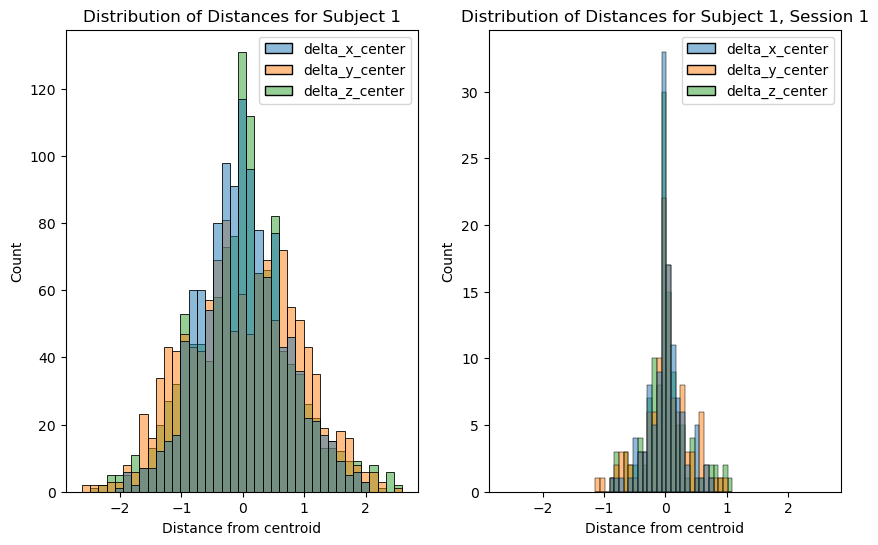

In [47]:
fig, ax = plt.subplots(1,2, figsize=(10,6), sharex=True)
sns.histplot(sub1[['delta_x_center','delta_y_center','delta_z_center']], ax=ax[0])
ax[0].set_xlabel("Distance from centroid")
ax[0].set_title("Distribution of Distances for Subject 1")
sns.histplot(sub1s1[['delta_x_center','delta_y_center','delta_z_center']], ax=ax[1])
ax[1].set_xlabel("Distance from centroid")
ax[1].set_title("Distribution of Distances for Subject 1, Session 1")

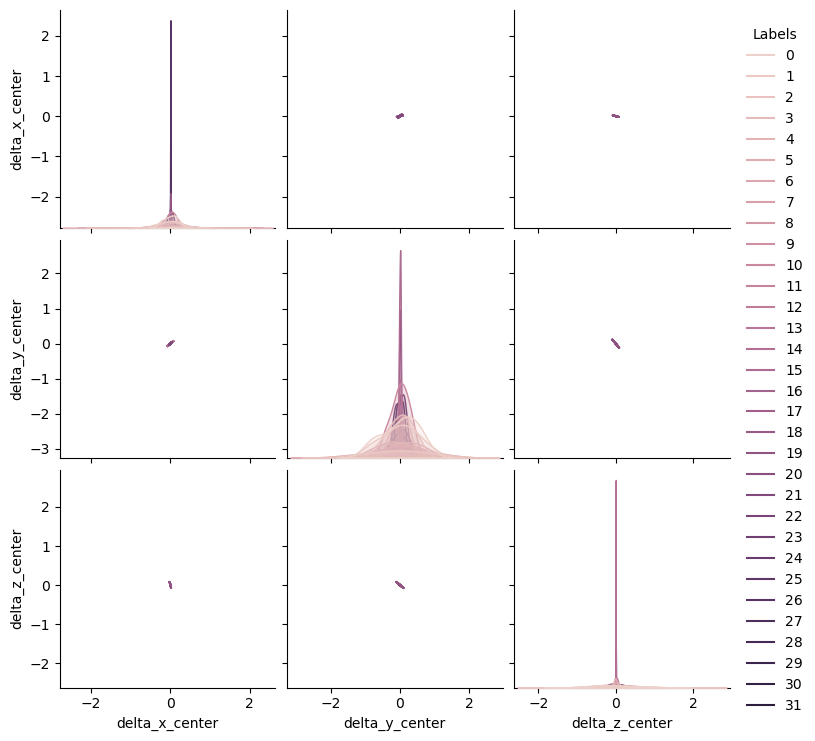

In [48]:
sns.pairplot(sub1s1[['Labels','delta_x_center','delta_y_center','delta_z_center']], hue='Labels', kind='kde')

<Axes: xlabel='Labels', ylabel='delta_x_center'>

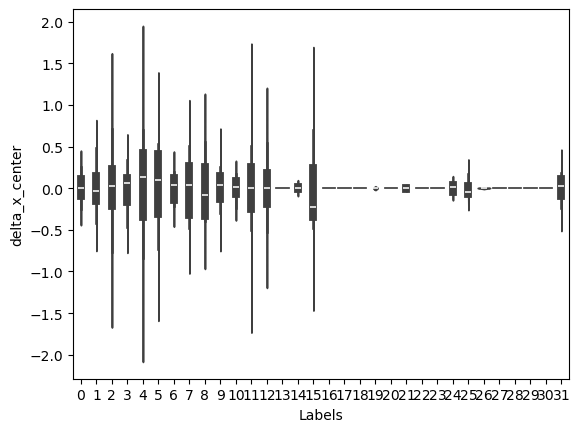

In [49]:
sns.violinplot(sub1s1[['Labels','delta_x_center','delta_y_center','delta_z_center']], x="Labels", y="delta_x_center")

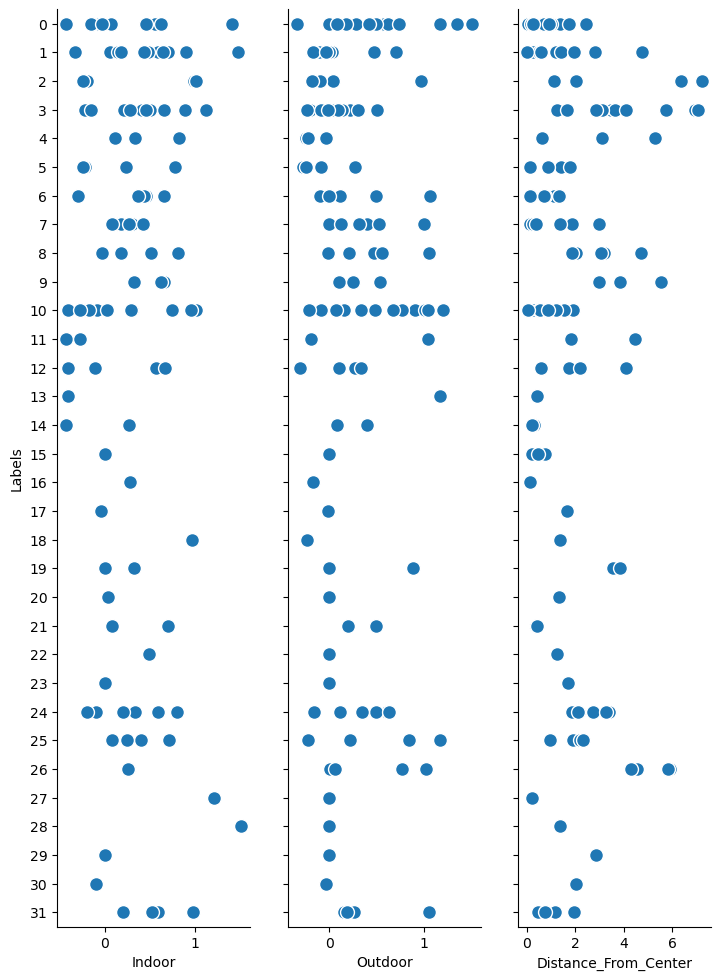

In [50]:
g = sns.PairGrid(sub1s1.sort_values("Labels", ascending=True),
                 x_vars=sub1.columns[-3:], y_vars=["Labels"],
                 height=10, aspect=.25)

g.map(sns.stripplot, size=10, orient="h", jitter=False,
      palette="flare_r", linewidth=1, edgecolor="w")


Subject 1, Session 10

In [51]:
X = sub1[sub1['Session']==1].loc[:,['x','y','z']]

In [52]:
connectivity = kneighbors_graph(X, n_neighbors=12, include_self=False)
model = AgglomerativeClustering(n_clusters=32, linkage='ward', connectivity=connectivity).fit(X)

In [53]:
sub1s10 = sub1[sub1['Session']==10].copy()
sub1s10['Labels'] = model.labels_

In [54]:
centers = sub1s10.groupby('Labels')[['x', 'y', 'z']].mean()

In [55]:
cdf = centers.loc[sub1s10['Labels'], ['x', 'y', 'z']]
cdf.index = sub1s10.index
cdf.shape

(121, 3)

In [56]:
sub1s10[['delta_x_center','delta_y_center','delta_z_center']] = cdf[['x', 'y', 'z']] - sub1s10[['x', 'y', 'z']]

Text(0.5, 1.0, 'Distribution of Distances for Subject 1, Session 10')

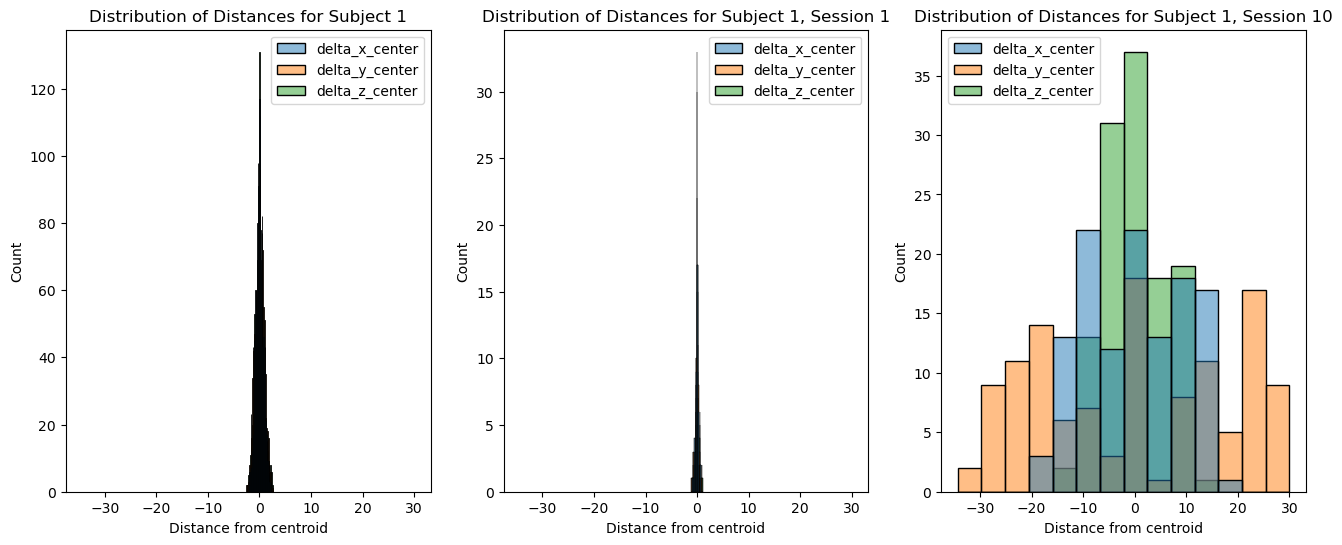

In [58]:
fig, ax = plt.subplots(1,3, figsize=(16,6), sharex=True)
sns.histplot(sub1[['delta_x_center','delta_y_center','delta_z_center']], ax=ax[0])
ax[0].set_xlabel("Distance from centroid")
ax[0].set_title("Distribution of Distances for Subject 1")
sns.histplot(sub1s1[['delta_x_center','delta_y_center','delta_z_center']], ax=ax[1])
ax[1].set_xlabel("Distance from centroid")
ax[1].set_title("Distribution of Distances for Subject 1, Session 1")
sns.histplot(sub1s10[['delta_x_center','delta_y_center','delta_z_center']], ax=ax[2])
ax[2].set_xlabel("Distance from centroid")
ax[2].set_title("Distribution of Distances for Subject 1, Session 10")

Text(0.5, 1.0, 'Distribution of Distances for Subject 1, Session 10')

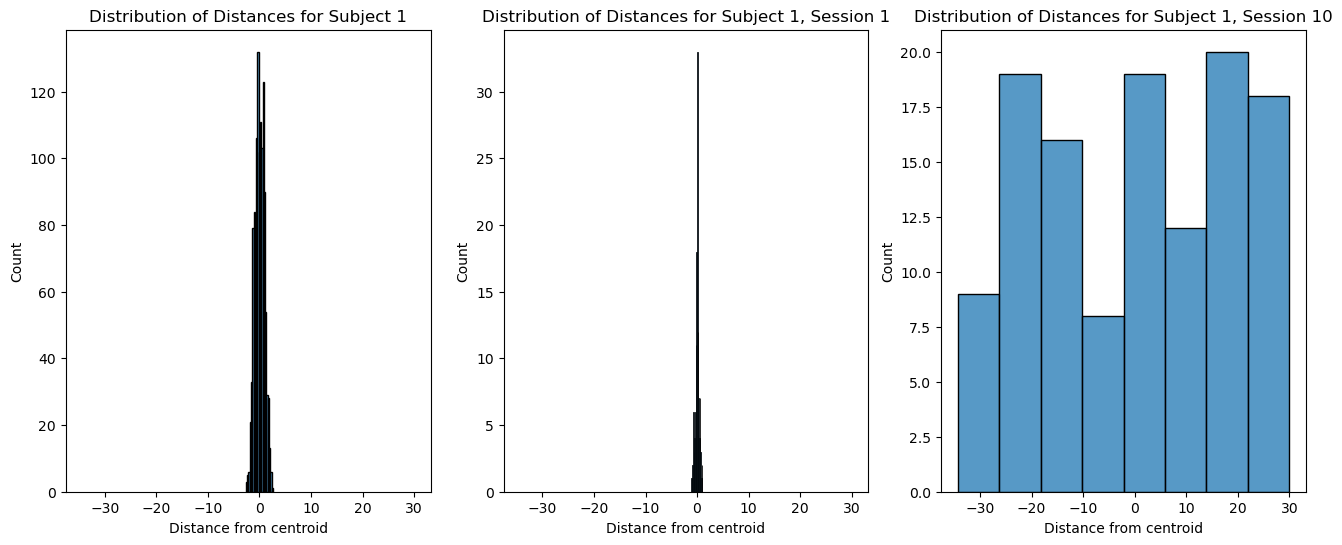

In [59]:
fig, ax = plt.subplots(1,3, figsize=(16,6), sharex=True)
sns.histplot(sub1['delta_y_center'], ax=ax[0])
ax[0].set_xlabel("Distance from centroid")
ax[0].set_title("Distribution of Distances for Subject 1")
sns.histplot(sub1s1['delta_y_center'], ax=ax[1])
ax[1].set_xlabel("Distance from centroid")
ax[1].set_title("Distribution of Distances for Subject 1, Session 1")
sns.histplot(sub1s10['delta_y_center'], ax=ax[2])
ax[2].set_xlabel("Distance from centroid")
ax[2].set_title("Distribution of Distances for Subject 1, Session 10")

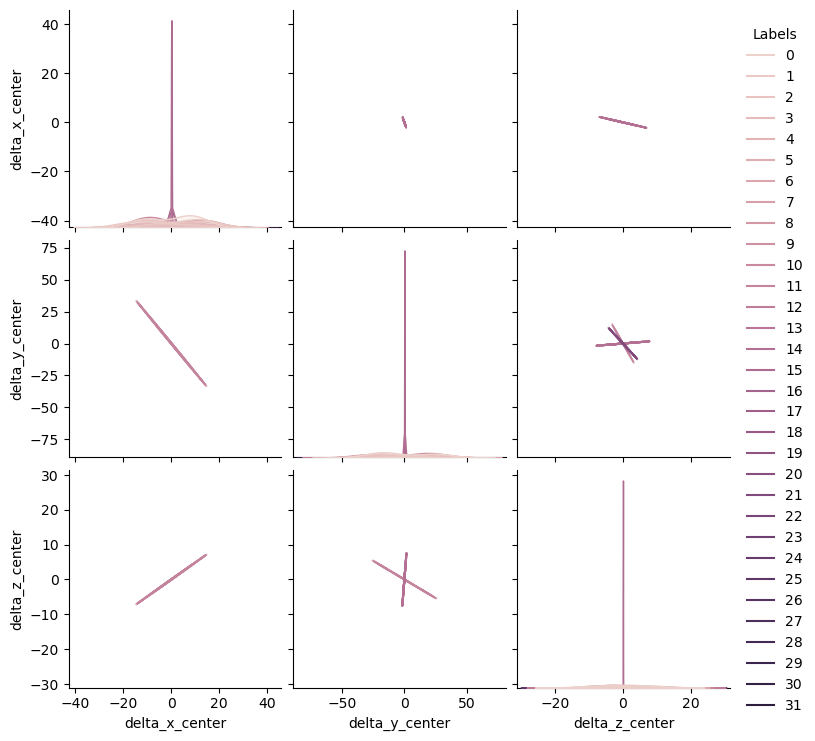

In [60]:
sns.pairplot(sub1s10[['Labels','delta_x_center','delta_y_center','delta_z_center']], hue='Labels', kind='kde')

In [68]:
(sub1.Indoor.max() - sub1.Indoor.min())/20

0.10403902836163961

In [ ]:
sub1s10['Indoor'] = sub1['Indoor'][sub1['Session']==10]

In [94]:
sub1s1['Indoor'] = sub1['Indoor'][sub1['Session']==1]

In [71]:
inbin = KBinsDiscretizer(n_bins=20, encode='ordinal', strategy='uniform')
s10_indoor = inbin.fit_transform(sub1s10['Indoor'].to_numpy().reshape(-1, 1))

In [72]:
sub1s10['Indoor_Binned'] = s10_indoor

In [95]:
inbin = KBinsDiscretizer(n_bins=20, encode='ordinal', strategy='uniform')
s1_indoor = inbin.fit_transform(sub1s1['Indoor'].to_numpy().reshape(-1, 1))

In [96]:
sub1s1['Indoor_Binned'] = s1_indoor

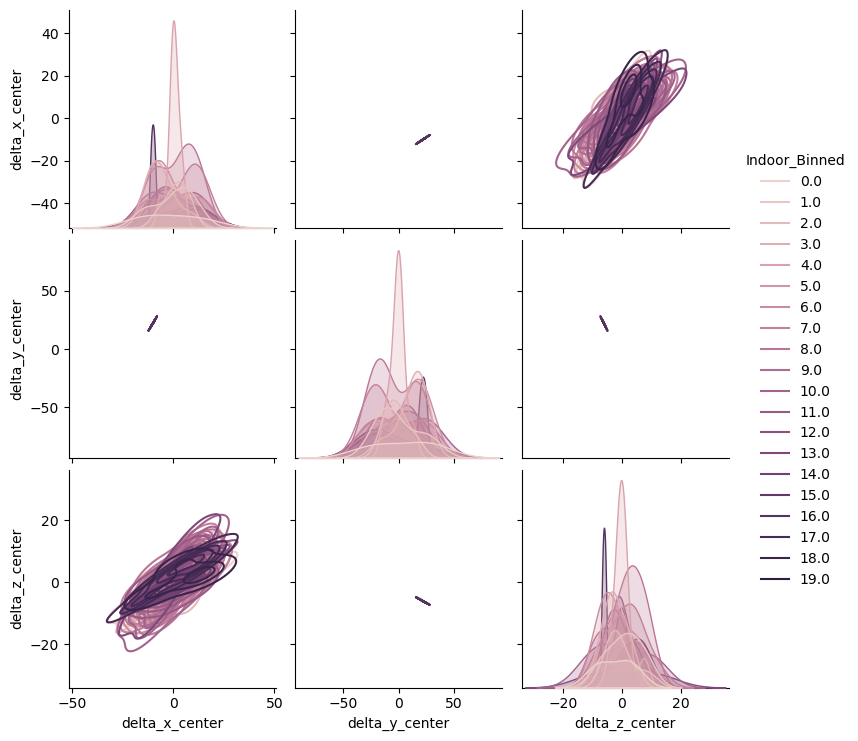

In [73]:
sns.pairplot(sub1s10[['Indoor_Binned','delta_x_center','delta_y_center','delta_z_center']], hue='Indoor_Binned', kind='kde')

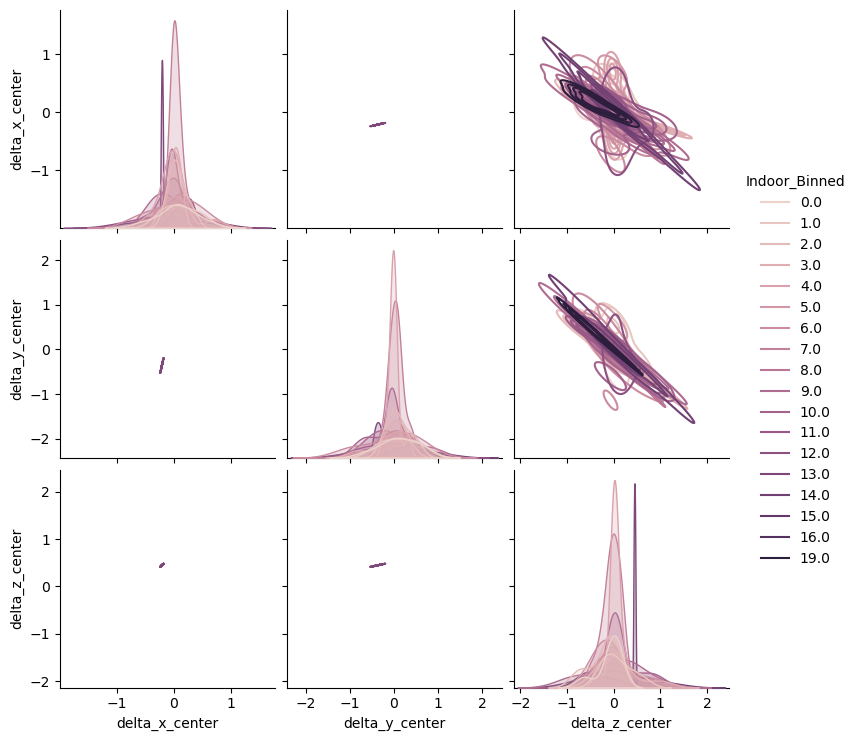

In [97]:
sns.pairplot(sub1s1[['Indoor_Binned','delta_x_center','delta_y_center','delta_z_center']], hue='Indoor_Binned', kind='kde')

In [80]:
sub1s10['Outdoor'] = sub1['Outdoor'][sub1['Session']==10]

In [87]:
outbin = KBinsDiscretizer(n_bins=20, encode='ordinal', strategy='uniform')
s10_outdoor = inbin.fit_transform(sub1s10['Outdoor'].to_numpy().reshape(-1, 1))

In [88]:
sub1s10['Outdoor_Binned'] = s10_outdoor

In [98]:
sub1s1['Outdoor'] = sub1['Outdoor'][sub1['Session']==1]

In [99]:
outbin = KBinsDiscretizer(n_bins=20, encode='ordinal', strategy='uniform')
s1_outdoor = inbin.fit_transform(sub1s1['Outdoor'].to_numpy().reshape(-1, 1))

In [100]:
sub1s1['Outdoor_Binned'] = s1_outdoor

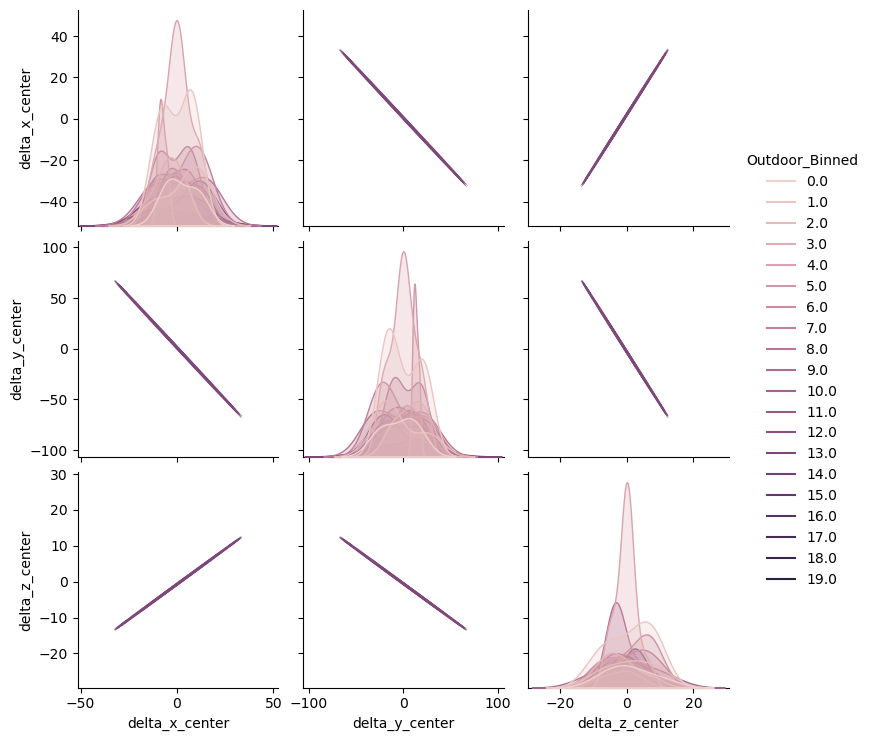

In [91]:
sns.pairplot(sub1s10[['Outdoor_Binned','delta_x_center','delta_y_center','delta_z_center']], hue='Outdoor_Binned', kind='kde')

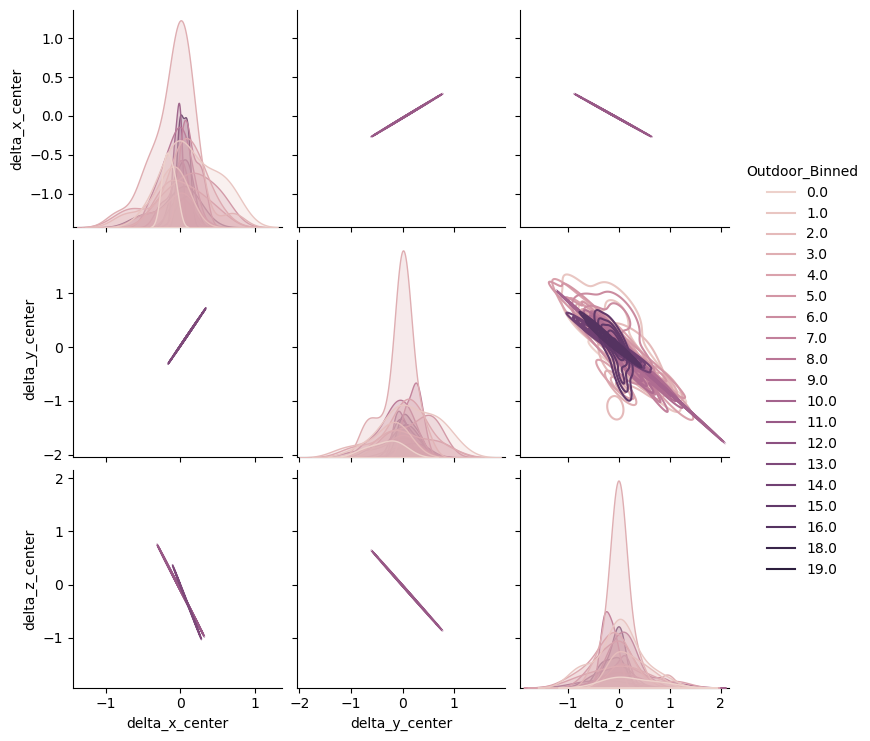

In [101]:
sns.pairplot(sub1s1[['Outdoor_Binned','delta_x_center','delta_y_center','delta_z_center']], hue='Outdoor_Binned', kind='kde')

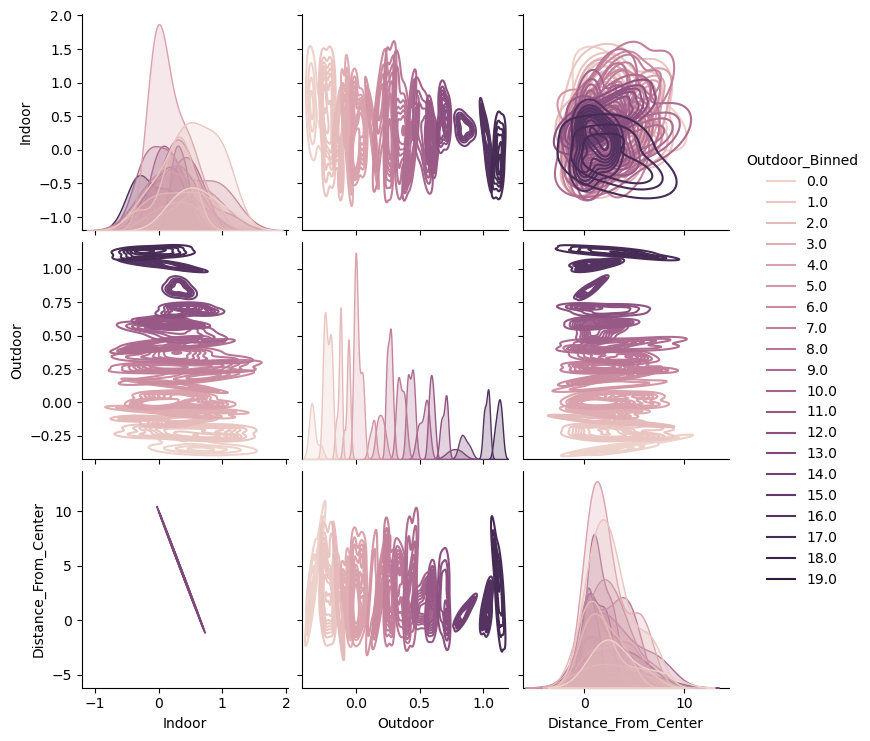

In [92]:
sns.pairplot(sub1s10[['Outdoor_Binned','Indoor','Outdoor','Distance_From_Center']], hue='Outdoor_Binned', kind='kde')

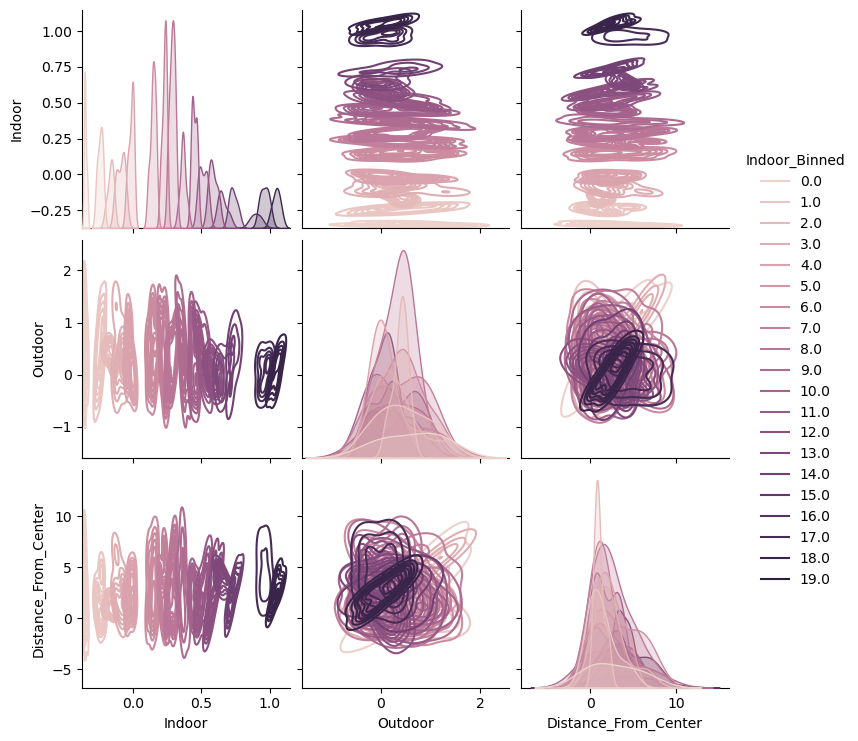

In [93]:
sns.pairplot(sub1s10[['Indoor_Binned','Indoor','Outdoor','Distance_From_Center']], hue='Indoor_Binned', kind='kde')

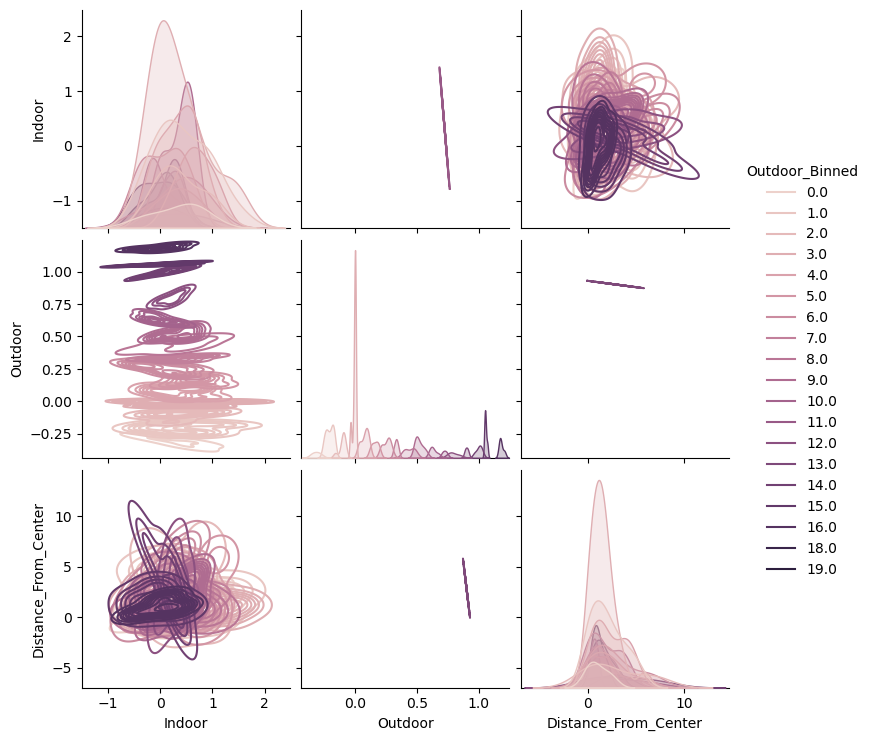

In [102]:
sns.pairplot(sub1s1[['Outdoor_Binned','Indoor','Outdoor','Distance_From_Center']], hue='Outdoor_Binned', kind='kde')

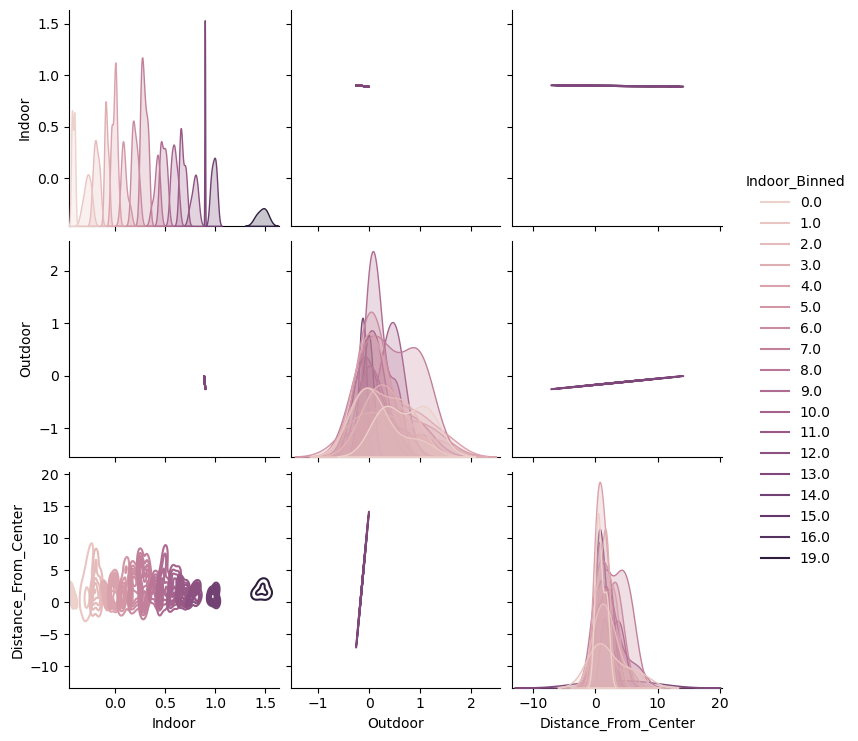

In [103]:
sns.pairplot(sub1s1[['Indoor_Binned','Indoor','Outdoor','Distance_From_Center']], hue='Indoor_Binned', kind='kde')

In [104]:
sub1s1.to_csv("./datasets/MSC01S01_rFEF_3D.csv")
sub1s10.to_csv("./datasets/MSC01S010_rFEF_3D.csv")

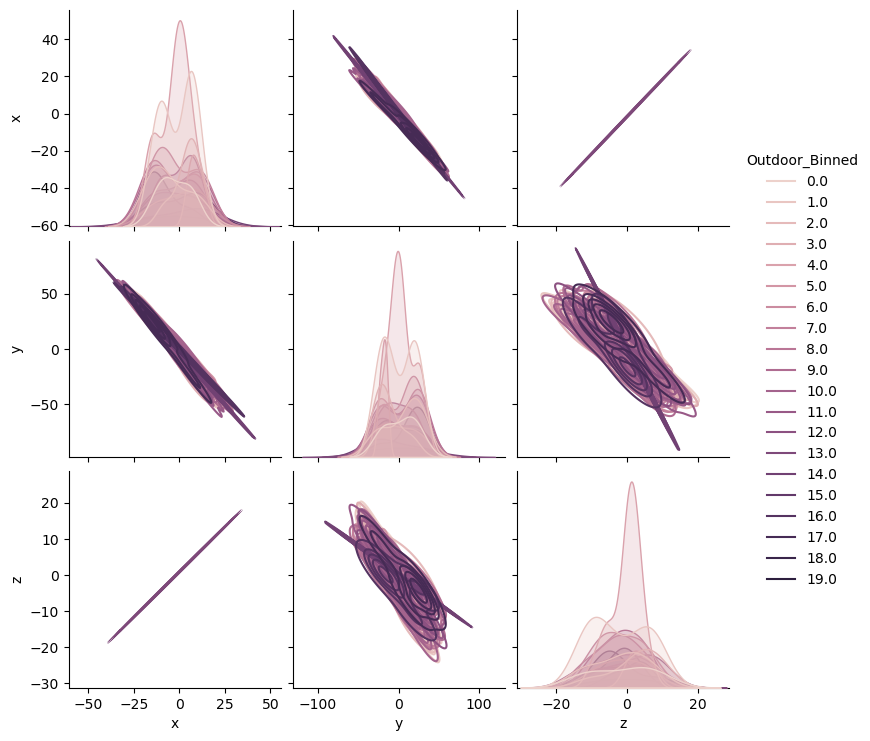

In [105]:
sns.pairplot(sub1s10[['Outdoor_Binned','x','y','z']], hue='Outdoor_Binned', kind='kde')

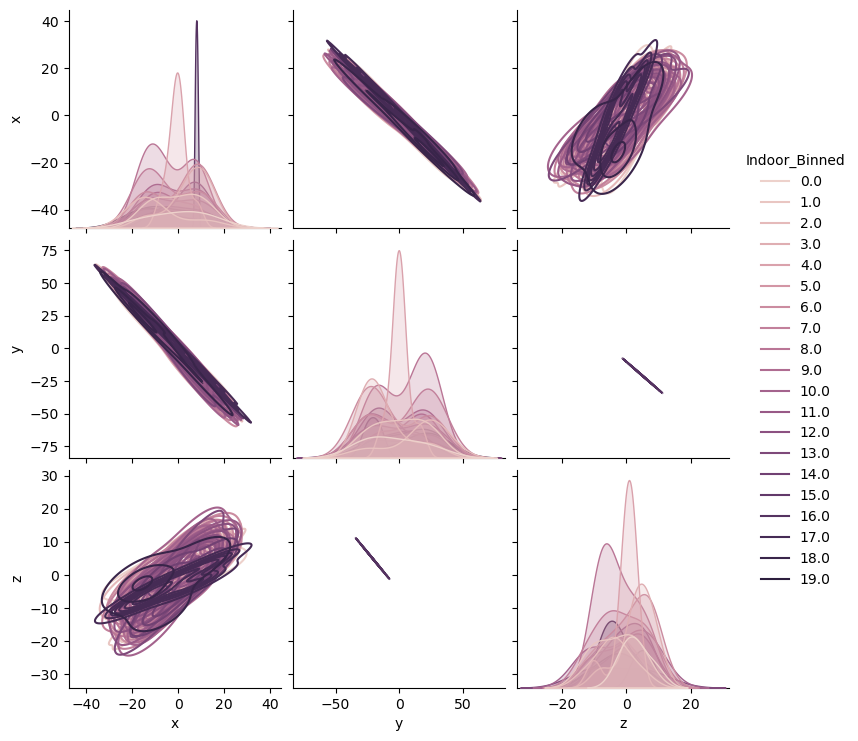

In [108]:
sns.pairplot(sub1s10[['Indoor_Binned','x','y','z']], hue='Indoor_Binned', kind='kde')

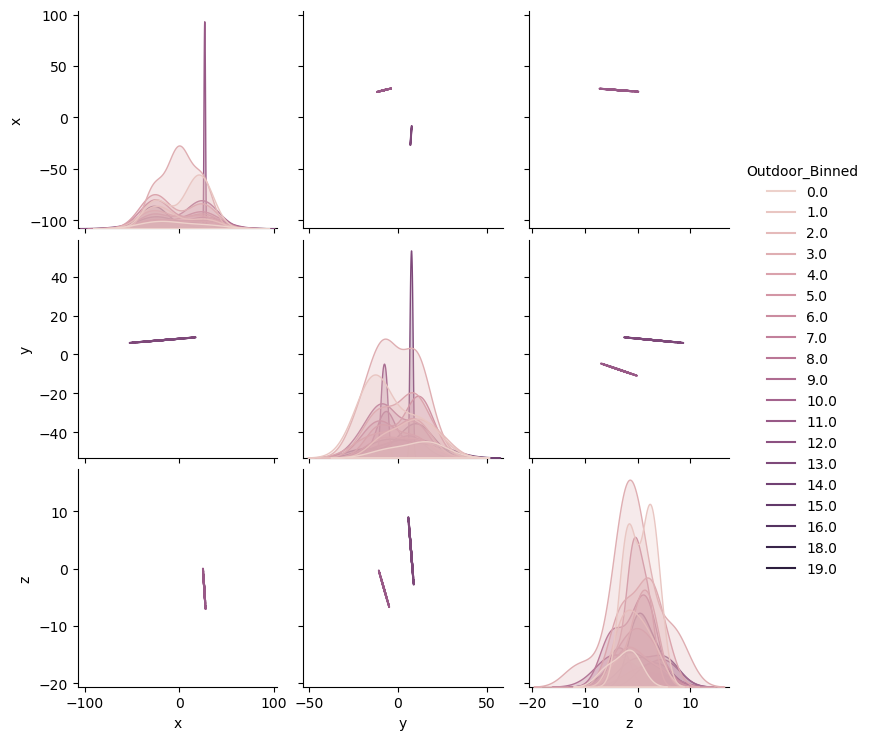

In [109]:
sns.pairplot(sub1s1[['Outdoor_Binned','x','y','z']], hue='Outdoor_Binned', kind='kde')

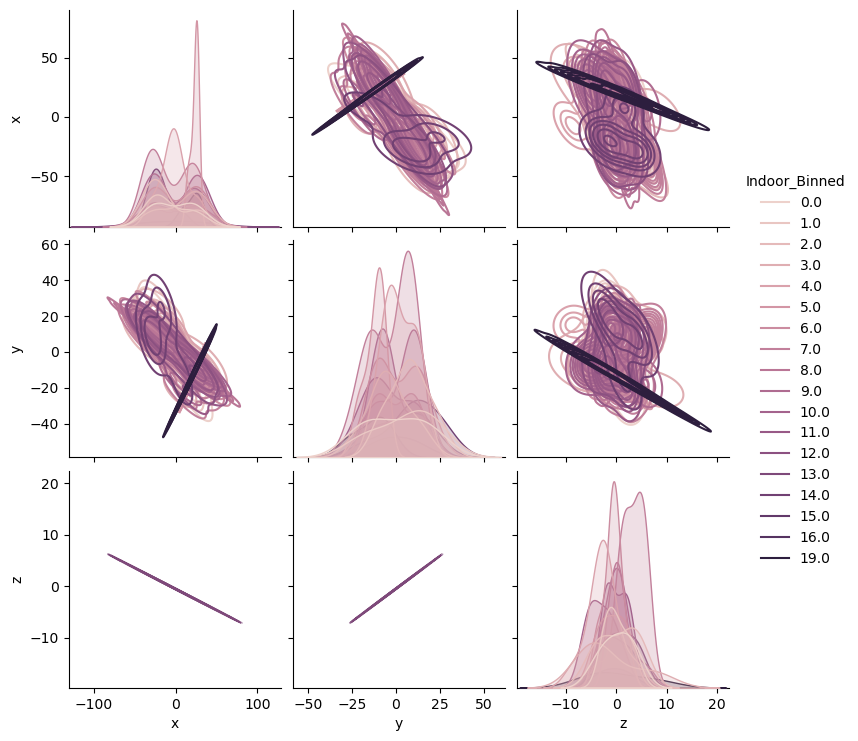

In [107]:
sns.pairplot(sub1s1[['Indoor_Binned','x','y','z']], hue='Indoor_Binned', kind='kde')

<Axes: xlabel='delta_x_center', ylabel='delta_y_center'>

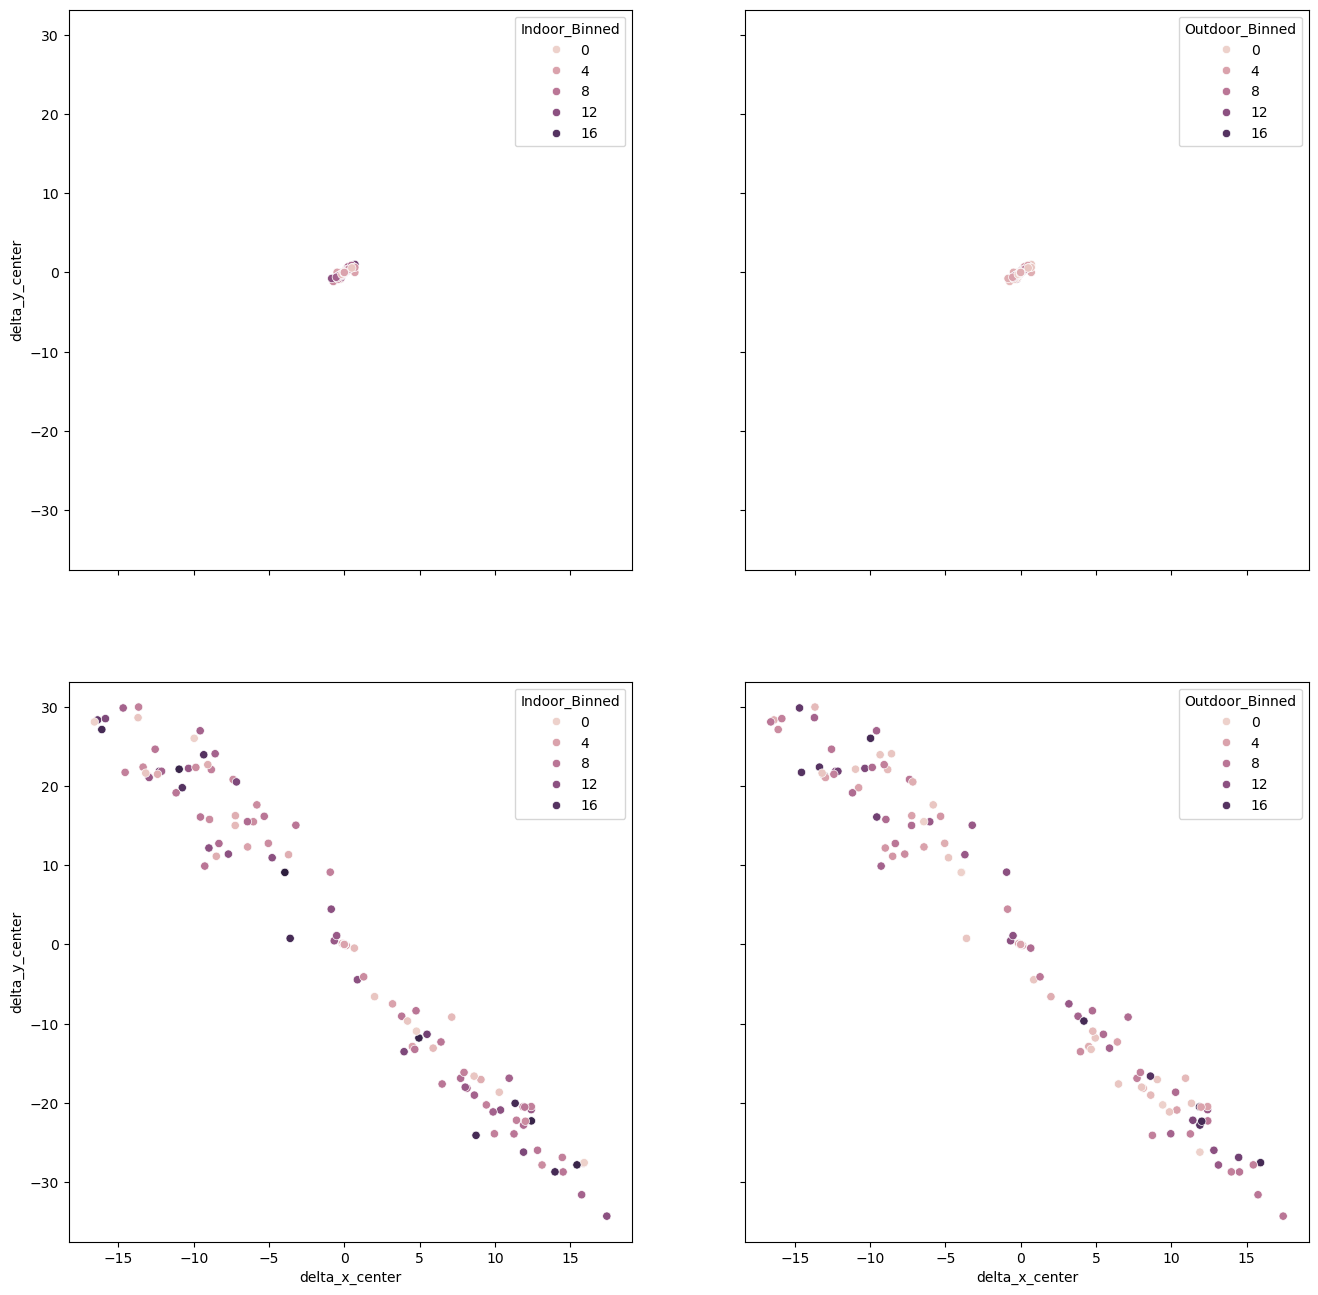

In [111]:
fig, ax = plt.subplots(2,2, figsize=(16,16), sharex=True, sharey=True)
sns.scatterplot(sub1s1, x='delta_x_center', y='delta_y_center', hue='Indoor_Binned', ax=ax[0,0])
sns.scatterplot(sub1s1, x='delta_x_center', y='delta_y_center', hue='Outdoor_Binned', ax=ax[0,1])
sns.scatterplot(sub1s10, x='delta_x_center', y='delta_y_center', hue='Indoor_Binned', ax=ax[1,0])
sns.scatterplot(sub1s10, x='delta_x_center', y='delta_y_center', hue='Outdoor_Binned', ax=ax[1,1])

<Axes: xlabel='delta_x_center', ylabel='delta_z_center'>

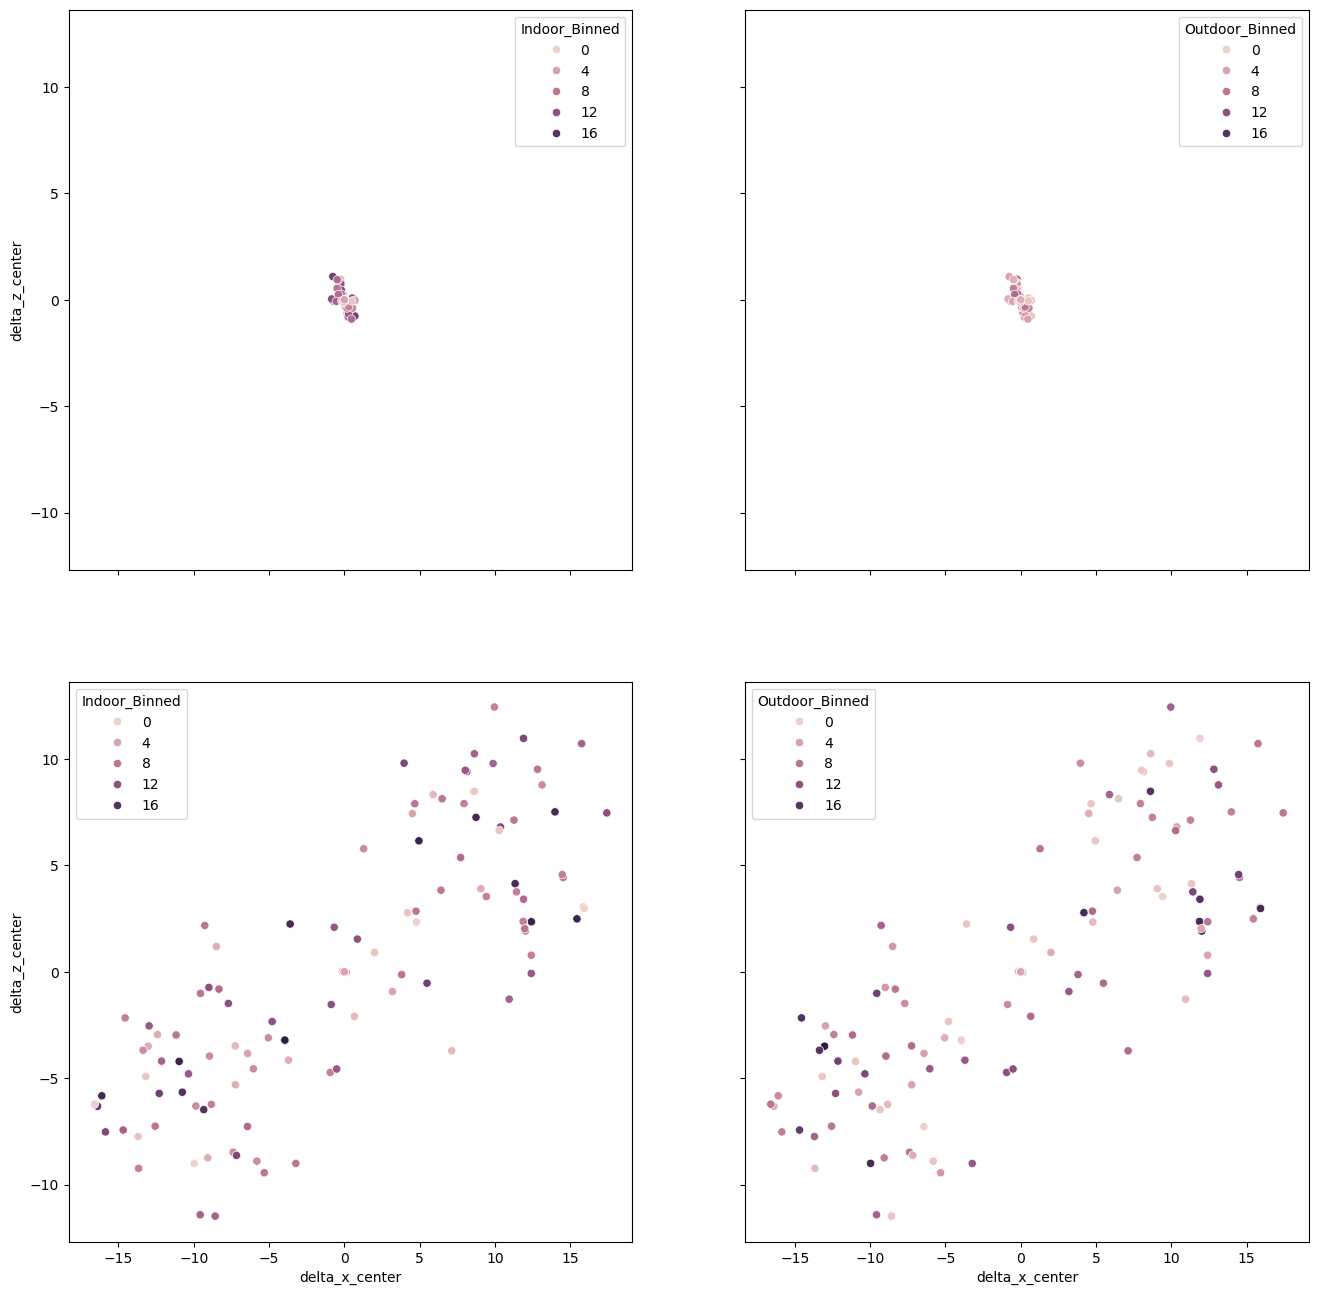

In [112]:
fig, ax = plt.subplots(2,2, figsize=(16,16), sharex=True, sharey=True)
sns.scatterplot(sub1s1, x='delta_x_center', y='delta_z_center', hue='Indoor_Binned', ax=ax[0,0])
sns.scatterplot(sub1s1, x='delta_x_center', y='delta_z_center', hue='Outdoor_Binned', ax=ax[0,1])
sns.scatterplot(sub1s10, x='delta_x_center', y='delta_z_center', hue='Indoor_Binned', ax=ax[1,0])
sns.scatterplot(sub1s10, x='delta_x_center', y='delta_z_center', hue='Outdoor_Binned', ax=ax[1,1])

<Axes: xlabel='delta_y_center', ylabel='delta_z_center'>

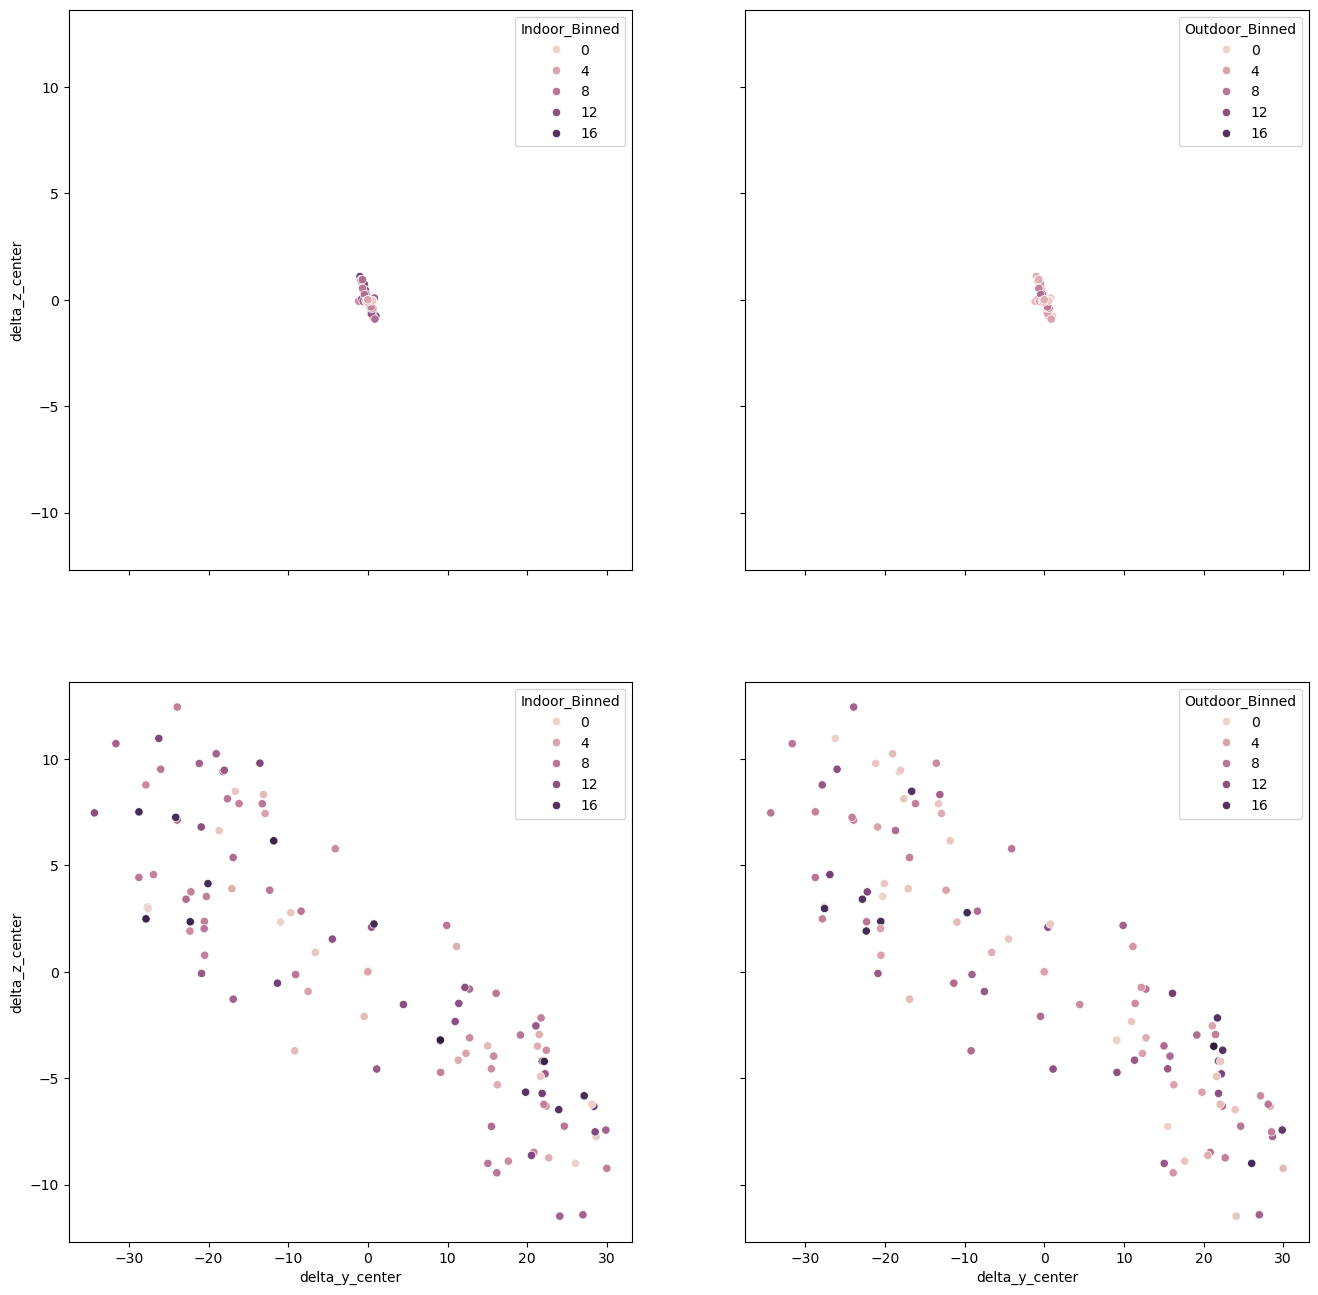

In [113]:
fig, ax = plt.subplots(2,2, figsize=(16,16), sharex=True, sharey=True)
sns.scatterplot(sub1s1, x='delta_y_center', y='delta_z_center', hue='Indoor_Binned', ax=ax[0,0])
sns.scatterplot(sub1s1, x='delta_y_center', y='delta_z_center', hue='Outdoor_Binned', ax=ax[0,1])
sns.scatterplot(sub1s10, x='delta_y_center', y='delta_z_center', hue='Indoor_Binned', ax=ax[1,0])
sns.scatterplot(sub1s10, x='delta_y_center', y='delta_z_center', hue='Outdoor_Binned', ax=ax[1,1])

In [114]:
sub1s1[['delta_x_center','delta_y_center','delta_z_center']].corr()

,delta_x_center,delta_y_center,delta_z_center
delta_x_center,1.000000,0.906569,-0.644245
delta_y_center,0.906569,1.000000,-0.816980
delta_z_center,-0.644245,-0.816980,1.000000


In [115]:
sub1s10[['delta_x_center','delta_y_center','delta_z_center']].corr()

,delta_x_center,delta_y_center,delta_z_center
delta_x_center,1.000000,-0.983063,0.785305
delta_y_center,-0.983063,1.000000,-0.867487
delta_z_center,0.785305,-0.867487,1.000000


<Axes: xlabel='Labels', ylabel='delta_x_center'>

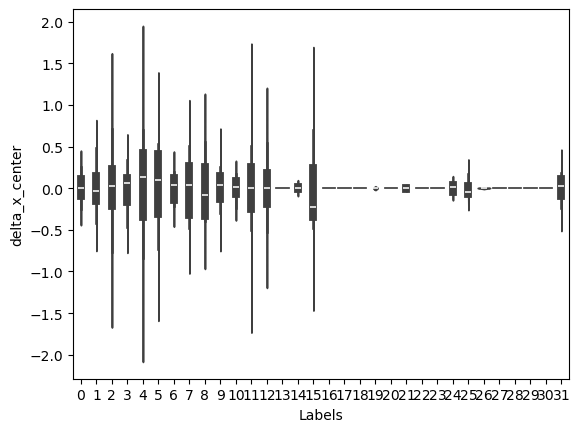

In [49]:
sns.violinplot(sub1s1[['Labels','delta_x_center','delta_y_center','delta_z_center']], x="Labels", y="delta_x_center")

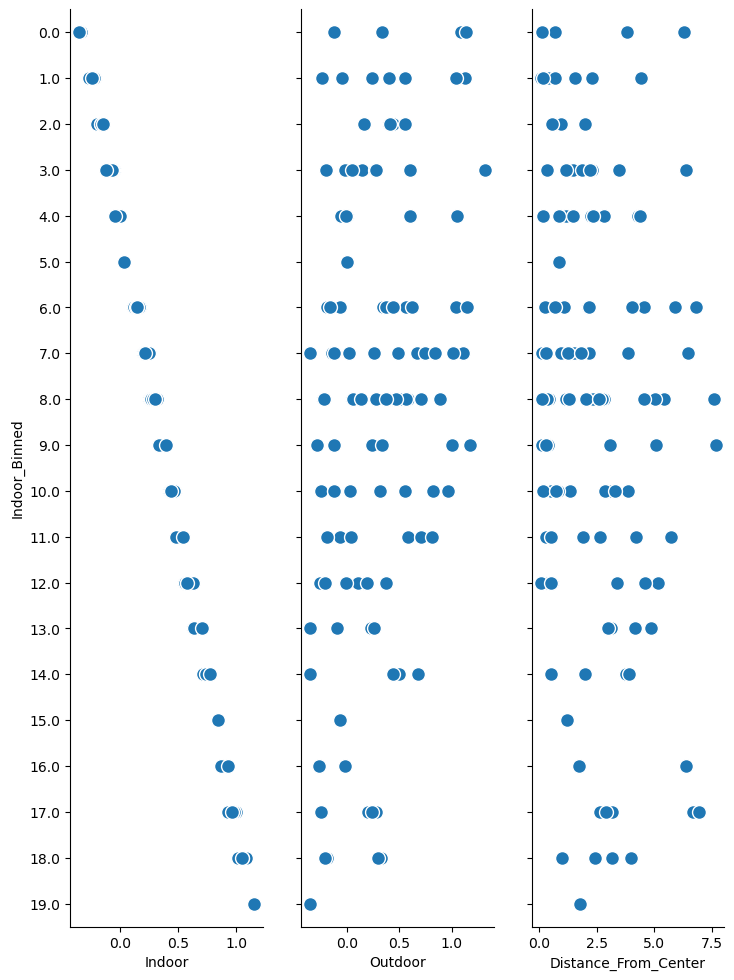

In [79]:
g = sns.PairGrid(sub1s10.sort_values("Indoor_Binned", ascending=True),
                 x_vars=sub1s10.columns[-4:-1], y_vars=["Indoor_Binned"],
                 height=10, aspect=.25)

g.map(sns.stripplot, size=10, orient="h", jitter=False,
      palette="flare_r", linewidth=1, edgecolor="w")


In [78]:
sub1s10.head()

,x,y,z,Time,Run,Subject,Session,Labels,delta_x_center,delta_y_center,delta_z_center,Indoor,Outdoor,Distance_From_Center,Indoor_Binned
1089,-0.061332,-0.955788,0.878829,0.0,10,1,10,15,-0.002211,0.007453,0.010756,0.0,0.0,1.164526,4.0
1090,0.063766,-1.057112,0.874733,2.2,10,1,10,15,-0.127308,0.108778,0.014852,0.0,0.0,1.441070,4.0
1091,-0.193061,-0.832104,0.915193,4.4,10,1,10,15,0.129519,-0.116231,-0.025608,0.0,0.0,0.846028,4.0
1092,0.739445,-1.778414,0.447632,6.6,10,1,10,29,0.000000,0.000000,0.000000,0.0,0.0,4.368268,4.0
1093,-1.902854,0.918461,1.371769,8.8,10,1,10,19,-6.421414,12.319907,-3.836218,0.0,0.0,2.814578,4.0


In [ ]:
class ManifoldAnalyzer:
    """
    A tool for detecting latent geometric states in high-dimensional 
    time-series data (e.g., fMRI, IoT sensors, User Behavior).
    """
    def __init__(self, n_clusters=32):
        self.n_clusters = n_clusters
        self.kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
        
    def fit_predict_geometry(self, df_run):
        """
        Analyzes the geometric structure (Manifold Twist) of a single session.
        
        Args:
            df_run (pd.DataFrame): Must contain 'x', 'y', 'z' columns.
            
        Returns:
            dict: The correlation coefficients between geometric axes.
                  High Negative Correlation = "Expert/Structured State"
                  High Positive Correlation = "Novice/Redundant State"
        """
        # 1. Extract Coordinates
        coords = df_run[['x', 'y', 'z']].values
        
        if len(coords) < self.n_clusters:
            return None # Not enough data

        # 2. Cluster the Manifold (Find the "Noodle Segments")
        labels = self.kmeans.fit_predict(coords)
        centers = self.kmeans.cluster_centers_
        
        # 3. Calculate "Deltas" (Radial Vectors from Center to Point)
        # This measures the cross-section shape of the manifold
        center_coords = centers[labels]
        deltas = coords - center_coords
        
        # 4. Calculate Axis Correlations (The "Twist" Metric)
        df_deltas = pd.DataFrame(deltas, columns=['dx', 'dy', 'dz'])
        corr_mat = df_deltas.corr()
        
        return {
            'Corr_XY': corr_mat.loc['dx', 'dy'],
            'Corr_XZ': corr_mat.loc['dx', 'dz'],
            'Corr_YZ': corr_mat.loc['dy', 'dz'],
            'Volume_LogDet': np.linalg.slogdet(df_run[['x', 'y', 'z']].cov())[1]
        }